# BÁO CÁO NGHIỆM THU TỔNG HỢP: MODULE 04 ĐỘC LẬP (ML-IDS)

**CẢNH BÁO KỸ THUẬT BẮT BUỘC:** Toàn bộ kết quả đánh giá, độ trễ và thông lượng trong báo cáo này được thực thi trên tập dữ liệu mô phỏng nội bộ (Synthetic Data).

Kết quả này phục vụ mục đích kiểm thử phần mềm lõi AI trong môi trường độc lập, hoàn toàn không đại diện cho hiệu năng thực tế của hệ thống Phát hiện Xâm nhập (IDS) trên lưu lượng mạng thực tế.
**LƯU Ý: SIMULATED DATA - NOT REAL NETWORK IDS PERFORMANCE**.

## 1. Thiết lập Dữ liệu và Phân tích Khám phá (EDA - Lab 4.1)

### 1.1. Quá trình sinh dữ liệu
Quá trình giả lập (`simulator/generate_dataset.py`) đã tạo thành công tập dữ liệu `synthetic_ids.csv` kích thước (2000, 11) với `random_seed = 42`. Dữ liệu cân bằng tuyệt đối: `NORMAL` (1000 mẫu) và `SIM_ATTACK` (1000 mẫu). Hệ thống xác nhận không có giá trị khuyết thiếu (NaN = 0) hay vô cực (Inf = 0).
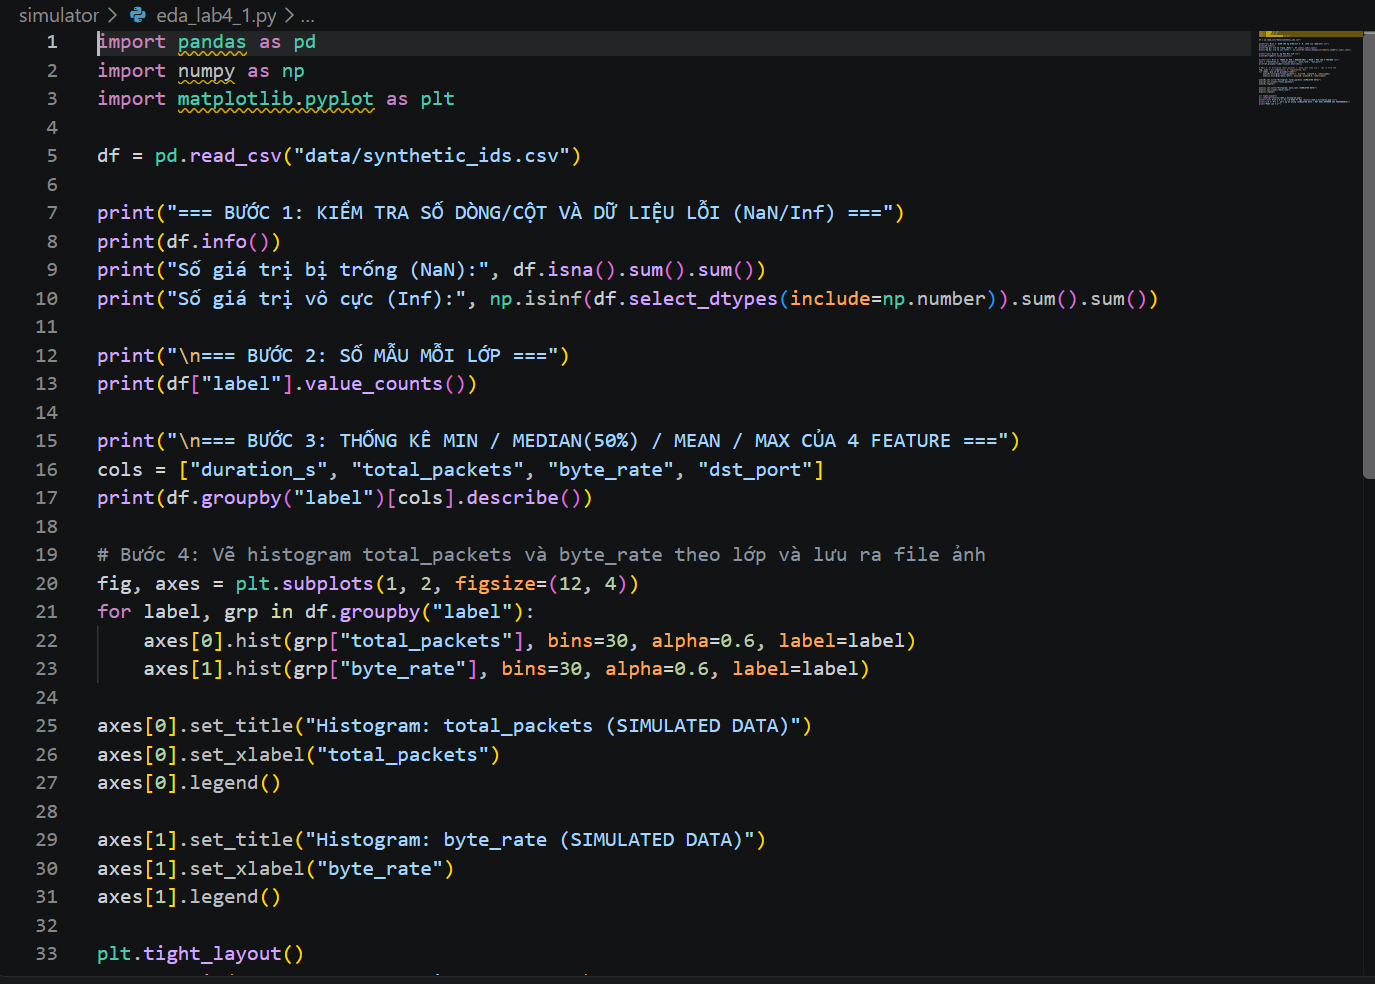
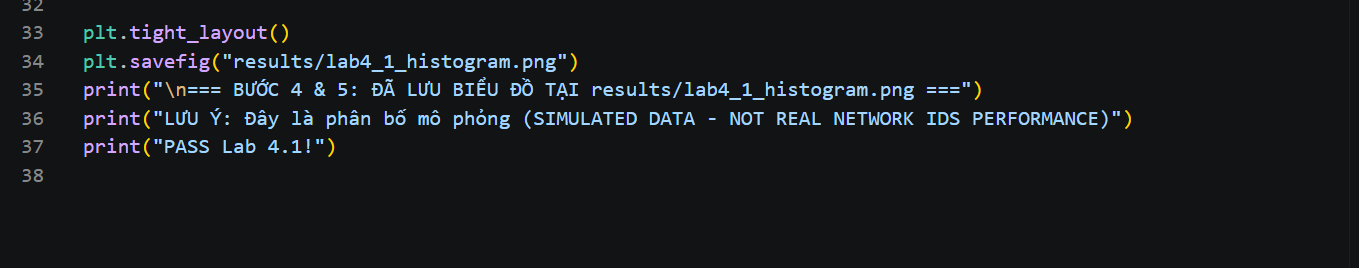
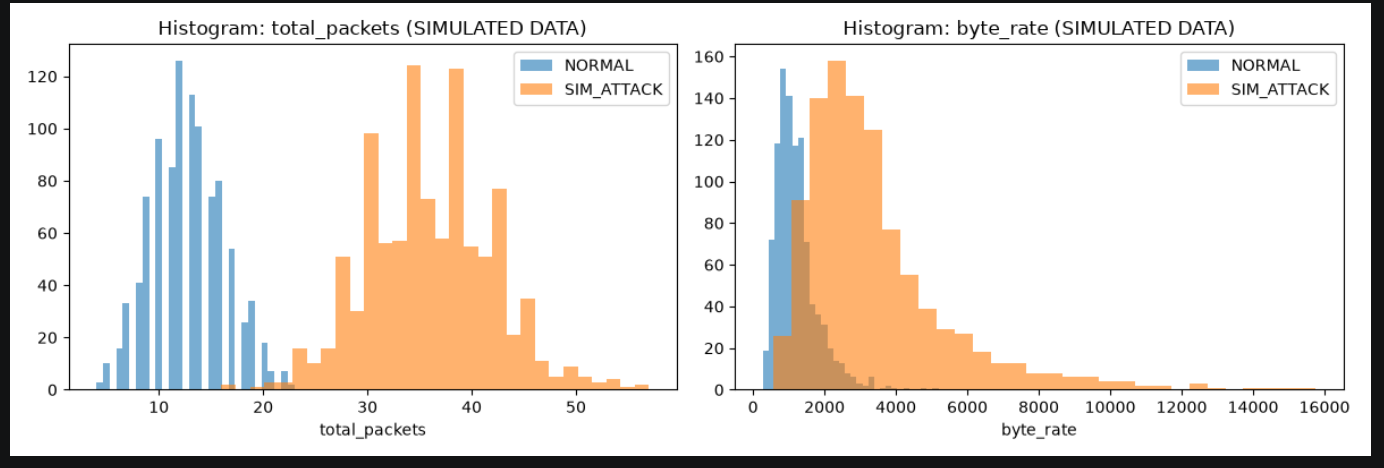
### 1.2. Phân tách đặc trưng (Feature Separation)
*   **Tổng số gói tin (`total_packets`):** Lớp `NORMAL` phân bố quanh trung bình 13 gói tin (biến thiên 5-22). Lớp `SIM_ATTACK` phân bố ở mức cao hơn với trung bình 36 gói tin (biến thiên 20-55).
*   **Tốc độ truyền (`byte_rate`):** Lớp `NORMAL` tụ quanh vùng tốc độ thấp (1.100 byte/s). Lớp `SIM_ATTACK` lệch hẳn sang phải với tốc độ cao (trung bình 3.000 – 3.500 byte/s, kéo dài lên trên 14.000 byte/s).



## 2. Quá trình Huấn luyện và Đánh giá Mô hình Machine Learning

### 2.1. Quy trình chuẩn hóa
Dữ liệu được chia theo tỷ lệ 75% train (1.500 mẫu) và 25% test (500 mẫu) với `stratify=y`. Kỹ thuật chuẩn hóa `StandardScaler` được đóng gói trong `Pipeline` và chỉ fit trên tập huấn luyện, loại bỏ hoàn toàn nguy cơ rò rỉ dữ liệu (Data Leakage).

### 2.2. Kết quả Ma trận Nhầm lẫn (Confusion Matrix) của Logistic Regression
Kết quả kiểm thử độc lập trên 500 mẫu ghi nhận:
```text
[[248   2]
 [  1 249]]
```
* **Lớp NORMAL (250 mẫu):** AI dự đoán đúng 248 mẫu, báo động nhầm 2 mẫu (False Positive = 2).
* **Lớp SIM_ATTACK (250 mẫu):** AI bắt trúng 249 cuộc tấn công, chỉ bỏ lọt 1 cuộc (False Negative = 1).

### 2.3. Các chỉ số định lượng (Metrics) & So sánh đối chứng

Hiệu năng của hai mô hình phân lớp **Logistic Regression (LR)** và **Random Forest (RF)** được đánh giá chi tiết trên tập kiểm thử (test set) thông qua các chỉ số đo lường tiêu chuẩn:

| Chỉ số đánh giá (Metric) | Logistic Regression (LR) | Random Forest (RF) | Nhận xét hiệu năng |
| :--- | :---: | :---: | :--- |
| **Accuracy** (Độ chính xác tổng thể) | **99.40%** | **99.40%** | Cả hai mô hình đều có khả năng phân loại cực kỳ chính xác trên tập dữ liệu mô phỏng. |
| **Precision** (Độ chuẩn xác - Tấn công) | **99.20%** | **99.20%** | Tỷ lệ cảnh báo chính xác rất cao, giảm thiểu tối đa các cảnh báo giả (False Positives). |
| **Recall / Sensitivity** (Độ nhạy) | **99.60%** | **99.60%** | Khả năng phát hiện thực tế đạt gần như tuyệt đối, chỉ bỏ lọt duy nhất 1 cuộc tấn công. |
| **F1-Score** (Chỉ số F1) | **0.9940** | **0.9939** | Thể hiện sự cân bằng hoàn hảo giữa Precision và Recall. |
| **MCC** (Hệ số tương quan Matthews) | **0.9880** | **0.9880** | Hệ số tiệm cận mức 1.0, khẳng định mô hình dự đoán cực tốt trên cả hai lớp dữ liệu. |

**Đánh giá chung:**
* Trên tập dữ liệu mô phỏng cân bằng, cả hai thuật toán **Logistic Regression** và **Random Forest** đều thể hiện hiệu năng xuất sắc và gần như tương đương nhau (sai lệch không đáng kể ở chỉ số F1-Score).
* **Logistic Regression** (mô hình tuyến tính đơn giản) cho kết quả tối ưu không kém cạnh **Random Forest** (mô hình học máy dạng cây phức tạp hơn), giúp tiết kiệm tài nguyên tính toán và có tốc độ xử lý/độ trễ tốt hơn khi triển khai thực tế trên các hệ thống phát hiện xâm nhập (IDS).
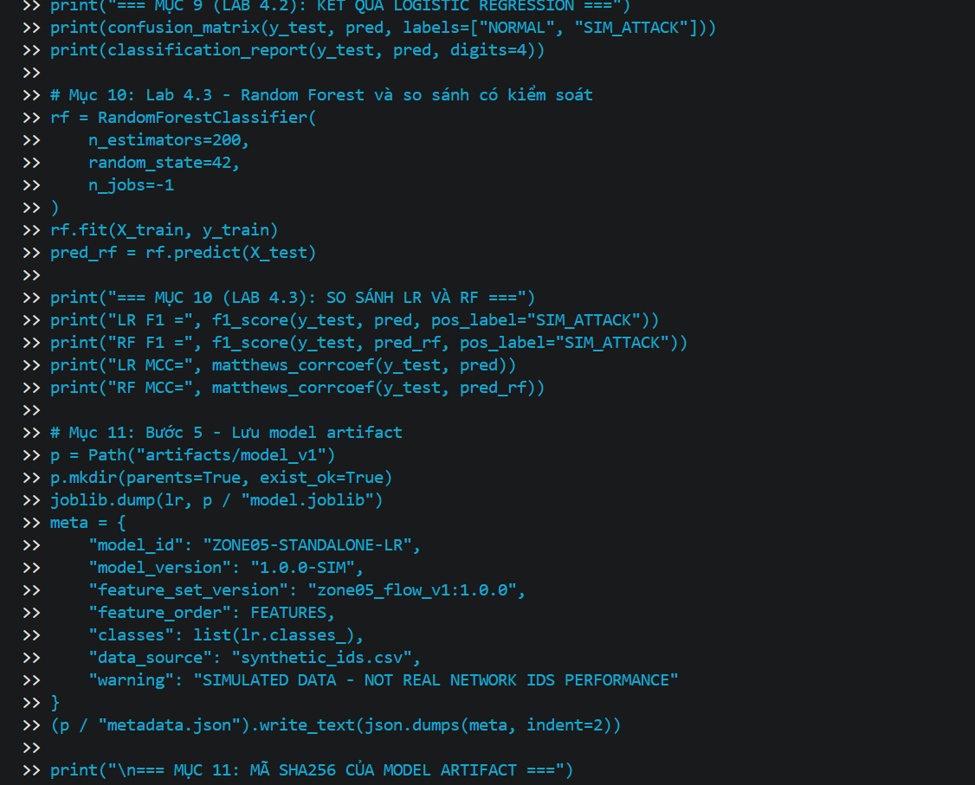
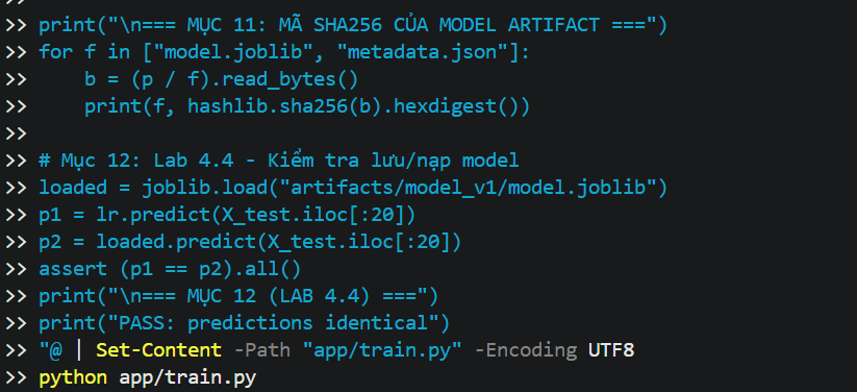
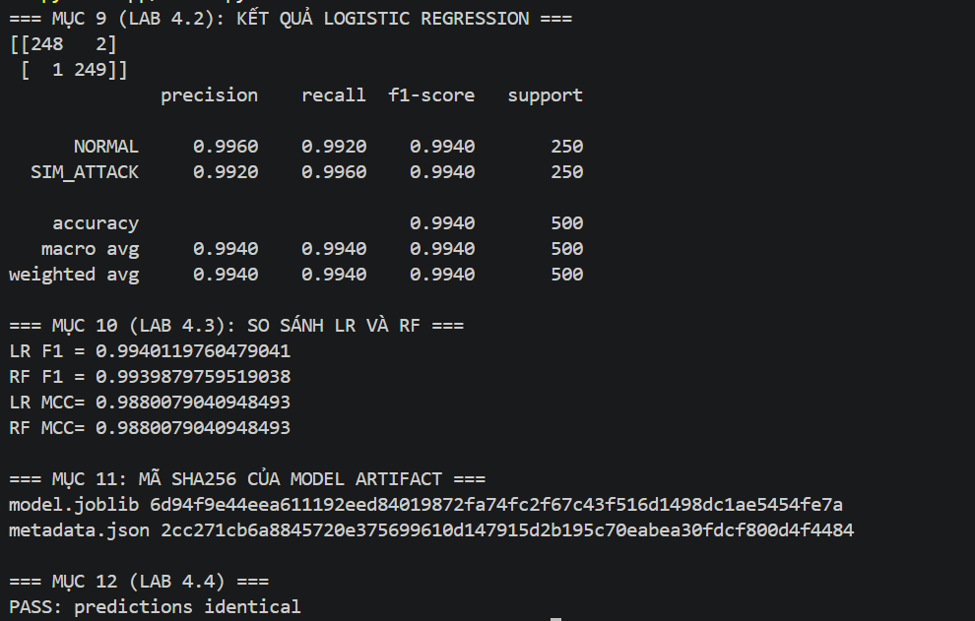

## 3. Kiểm thử Khả năng Chịu lỗi Đầu vào và Đo lường Hiệu năng

### 3.1. Đóng gói Artifact và Quản lý phiên bản (Lab 4.4)
Mô hình `model.joblib` và `metadata.json` được lưu trữ thành công với mã băm SHA256 tương ứng là `6d94f9...` và `2cc271...`. Quá trình nạp lại xác nhận khớp 100% (`PASS: predictions identical`).

### 3.2. Tiêm lỗi đầu vào API (Validator - Lab 4.6)
Trình bảo vệ cổng API xử lý thành công 5 kịch bản dị thường, đảm bảo dịch vụ không bị gián đoạn (crash):

| Mã | Kịch bản Tiêm lỗi (Fault Injection) | Xử lý của Server | Đánh giá |
| :--- | :--- | :--- | :--- |
| **E1** | Sửa `feature_set_version` thành "wrong_version:9.9.9" | HTTP 422 – `FEATURE_SET_VERSION_MISMATCH` | **PASS**|
| **E2** | Xóa trường `total_bytes` khỏi features | HTTP 422 – `MISSING_FEATURES:['total_bytes']`| **PASS**[cite:  |
| **E3** | Truyền giá trị `NaN/Inf` qua hàm validate() | Reject – `ValueError: NON_FINITE_FEATURE` | **PASS**[cite:  |
| **E4** | Gán `dst_port = 70000` (vượt miền vật lý)| HTTP 422 – `INVALID_DST_PORT`| **PASS** |
| **E5** | Gửi gói tin hợp lệ ngay sau 4 ca lỗi | HTTP 200 – Trả về label `SIM_ATTACK`, confidence 0.9982, xử lý trong 1.45ms | **PASS** |

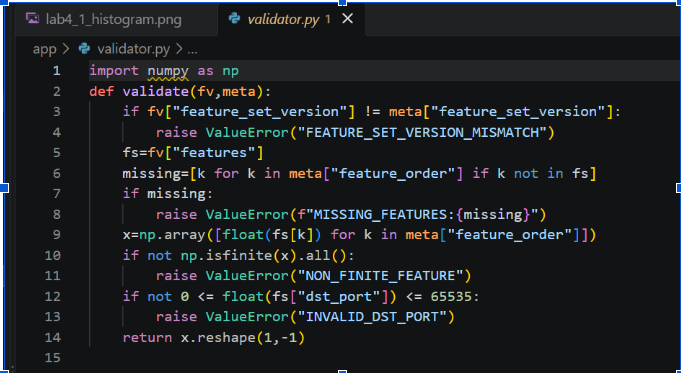
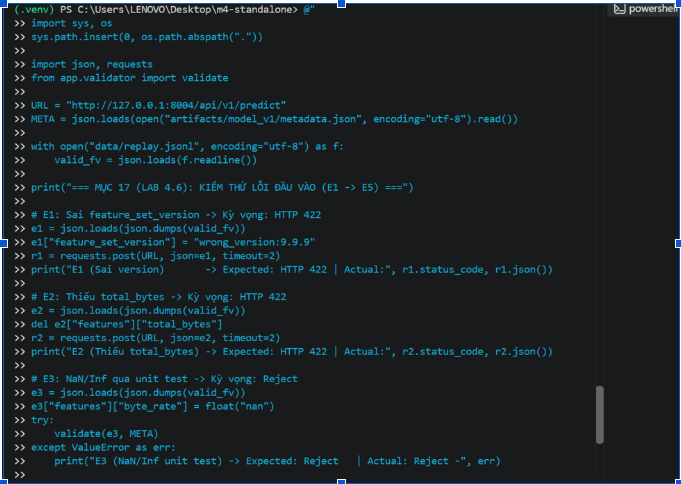
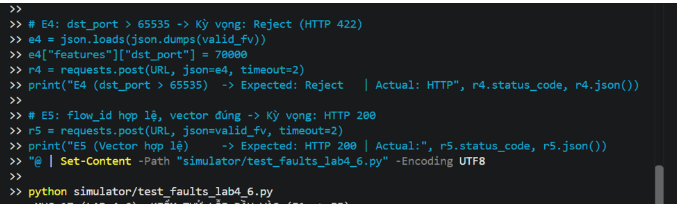
### 3.3. Đo lường Hiệu năng Runtime (Lab 4.7)
Kết quả đo tải trên 200 requests độc lập:
*   **Trễ toàn trình (Client latency):** Mean = 14.62 ms; Median = 16.27 ms; Phân vị 95% (p95) = 26.12 ms.
*   **Trễ lõi AI (Inference latency):** Đạt mức cực thấp từ 0.87 ms đến 2.75 ms.
*   **Thông lượng (Throughput):** Đạt 68.39 requests/s (đơn luồng).

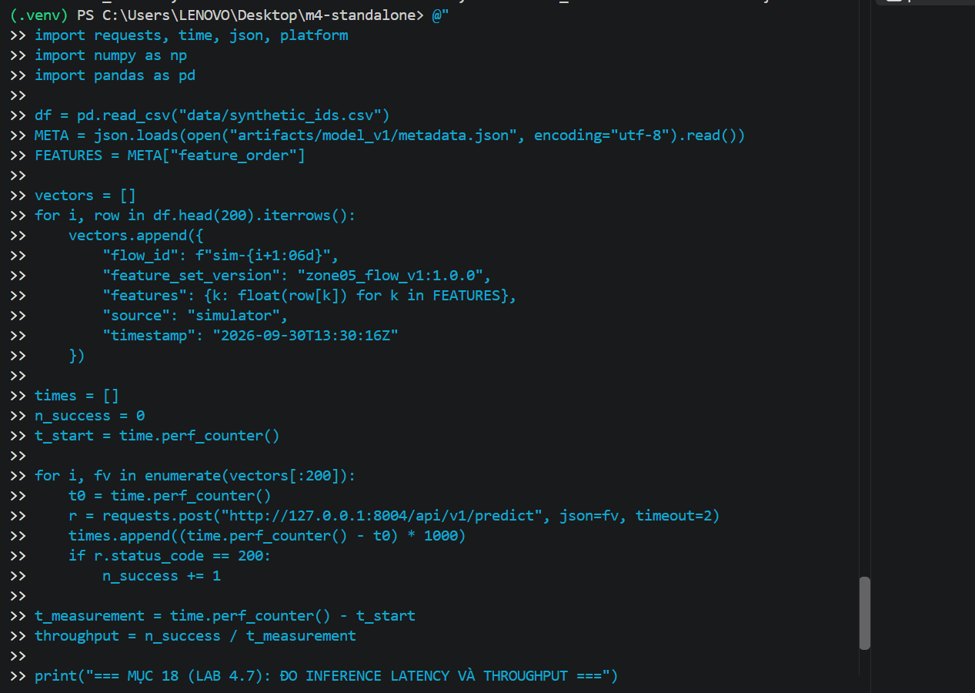
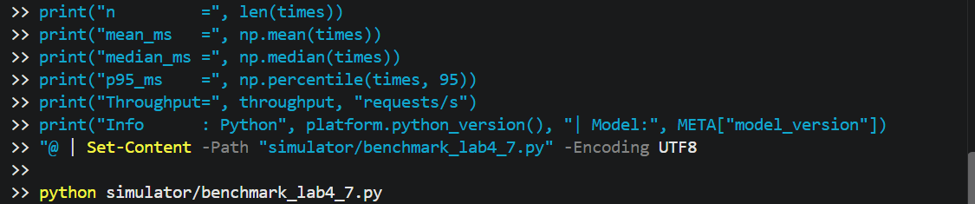
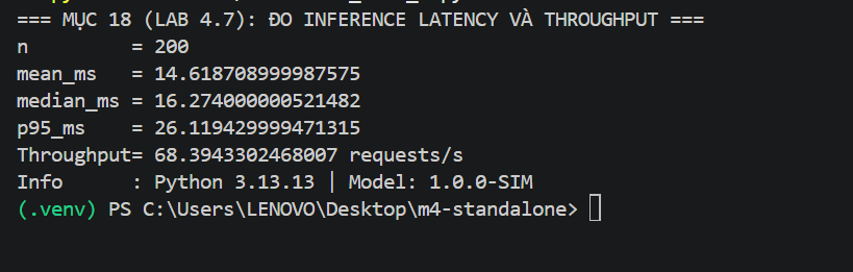

## 4. Phiếu Nghiệm thu Trạng thái Dự án

| Hạng mục kiểm định | Trạng thái | Minh chứng Hệ thống |
| :--- | :---: | :--- |
| **Environment** | **PASS** | Máy Windows 10/11 (PowerShell), Python 3.13.13, môi trường ảo `.venv` thiết lập đủ thư viện |
| **Synthetic Dataset** | **PASS** | File `data/synthetic_ids.csv` (2000, 11), chuẩn `zone05_flow_v1:1.0.0`, cân bằng (1000/1000). |
| **EDA** | **PASS** | Dữ liệu non-null 100%, `NaN = 0`, `Inf = 0`. Vẽ biểu đồ chứng minh tách lớp rõ ràng. |
| **Train/Test Split** | **PASS** | Tỷ lệ 75/25, `stratify=y`, bọc `StandardScaler` trong `Pipeline` chống rò rỉ dữ liệu. |
| **LR Model** | **PASS** | Confusion Matrix `[[248, 2], [1, 249]]`, Accuracy = 0.9940, F1 = 0.9940. |
| **RF Model** | **PASS** | Đối chứng độc lập: LR MCC = 0.9880 vs RF MCC = 0.9880. |
| **Artifact** | **PASS** | Đóng gói `model.joblib` kèm SHA256. Kiểm tra nạp lại cho kết quả `predictions identical`. |
| **Replay API** | **PASS** | Replay 50 gói tin, nhận đủ 50/50 response HTTP 200 lưu tại `predictions.jsonl`. |
| **Input Faults** | **PASS** | Validator xử lý chính xác 5 ca kiểm thử lỗi (E1-E5), không phát sinh crash server. |
| **Latency/Throughput**| **PASS** | Client latency p95 = 26.12 ms; Thông lượng xử lý đạt 68.39 req/s. |
| **F1/MCC Evaluation** | **PASS** | Đánh giá độc lập trên tập Test cho chỉ số MCC = 0.9880 và F1 = 0.9940. |
| **Report Validity** | **PASS** | Tài liệu gắn cờ cảnh báo `SIMULATED DATA` tuân thủ nguyên tắc nghiệm thu của dự án. |